# 🏘️ Choosing a Town in São Paulo State — Data Exploration

This notebook explores open datasets to help identify good municipalities to live in across the State of São Paulo, Brazil.  
We look at **quality of life, climate, tree/vegetation coverage, economics, and demographics**.

---

## Data Sources Catalog

| Domain | Source | What it provides | Access |
|--------|--------|-----------------|--------|
| **Demographics & Economics** | IBGE SIDRA API | Population, GDP per capita, age distribution, education | `https://apisidra.ibge.gov.br/` |
| **Human Development** | Atlas Brasil / PNUD | IDHM (Municipal HDI) — income, longevity, education | `http://www.interse.atlasbrasil.org.br/api/` |
| **Quality of Life Index** | SEADE / IMP | IPRS, IPVS, income, health, education for SP municipalities | `http://api-imp.seade.gov.br/v1/` |
| **Land Cover / Tree Coverage** | MapBiomas Collection 10 | Land use per municipality 1985–2024 (hectares by class) | `https://data.mapbiomas.org/` |
| **Climate** | INMET / Kaggle | Temperature, precipitation, humidity by station | `https://portal.inmet.gov.br/` or Kaggle |
| **Geographic Boundaries** | IBGE Geociências | Shapefiles / GeoJSON of all municipalities | `https://servicodados.ibge.gov.br/api/` |
| **Public Safety** | SSP-SP | Crime rates by municipality | `https://www.ssp.sp.gov.br/estatistica/` |
| **Sanitation & Infrastructure** | SNIS | Water, sewage coverage % | `http://app4.cidades.gov.br/serieHistorica/` |

## Setup

In [3]:
# Install required packages
!pip install pandas numpy matplotlib seaborn requests plotly geopandas folium scikit-learn openpyxl ipywidgets -q


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 1. Municipality List — IBGE Localities API

First we fetch the complete list of municipalities in SP (state code 35).

In [5]:
# Fetch all municipalities in São Paulo (UF code = 35)
url_mun = 'https://servicodados.ibge.gov.br/api/v1/localidades/estados/35/municipios'
resp = requests.get(url_mun)
municipios_raw = resp.json()

municipios = pd.DataFrame([{
    'cod_ibge': m['id'],
    'nome': m['nome'],
    'microrregiao': m['microrregiao']['nome'],
    'mesorregiao': m['microrregiao']['mesorregiao']['nome']
} for m in municipios_raw])

municipios['cod_ibge'] = municipios['cod_ibge'].astype(int)

print(f'Total municipalities in SP: {len(municipios)}')
municipios.head(10)

Total municipalities in SP: 645


,cod_ibge,nome,microrregiao,mesorregiao
0,3500105,Adamantina,Adamantina,Presidente Prudente
1,3500204,Adolfo,São José do Rio Preto,São José do Rio Preto
2,3500303,Aguaí,Pirassununga,Campinas
3,3500402,Águas da Prata,São João da Boa Vista,Campinas
4,3500501,Águas de Lindóia,Amparo,Campinas
5,3500550,Águas de Santa Bárbara,Avaré,Bauru
6,3500600,Águas de São Pedro,Piracicaba,Piracicaba
7,3500709,Agudos,Bauru,Bauru
8,3500758,Alambari,Itapetininga,Itapetininga
9,3500808,Alfredo Marcondes,Presidente Prudente,Presidente Prudente


---
## 2. Demographics — IBGE Census 2022 via SIDRA

We pull **population** (table 9514) from the 2022 Census and **estimated population 2024** (table 6579).  
The SIDRA API uses a URL-based query syntax: `/t/{table}/n6/{municipality_codes}/v/{variables}/p/{period}`.

In [6]:
# --- 2a. Population Census 2022 (Table 9514) ---
# n6/all = all municipalities; we filter SP afterwards
# v/93 = resident population; p/last = most recent period
url_pop = (
    'https://apisidra.ibge.gov.br/values'
    '/t/9514/n6/all/v/93/p/last'
    '/d/v93%200'
)
resp_pop = requests.get(url_pop)
pop_raw = resp_pop.json()

# First row is header metadata
pop_df = pd.DataFrame(pop_raw[1:])
pop_df = pop_df.rename(columns={
    'D1C': 'cod_ibge',
    'D1N': 'nome_municipio',
    'V': 'populacao_2022'
})
pop_df['cod_ibge'] = pop_df['cod_ibge'].astype(int)
pop_df['populacao_2022'] = pd.to_numeric(pop_df['populacao_2022'], errors='coerce')

# Filter to SP only (codes starting with 35)
pop_sp = pop_df[pop_df['cod_ibge'].astype(str).str.startswith('35')][['cod_ibge', 'populacao_2022']].copy()
pop_sp = pop_sp.reset_index(drop=True)

print(f'SP municipalities with population data: {len(pop_sp)}')
pop_sp.sort_values('populacao_2022', ascending=False).head(10)

SP municipalities with population data: 645


,cod_ibge,populacao_2022
562,3550308,11451999
212,3518800,1291771
108,3509502,1139047
544,3548708,810729
534,3547809,748919
387,3534401,728615
581,3552205,723682
487,3543402,698642
557,3549904,697054
556,3549805,480393


In [7]:
# Merge population into main dataframe
df = municipios.merge(pop_sp, on='cod_ibge', how='left')
print(f'Records after merge: {len(df)}')
df.sort_values('populacao_2022', ascending=False).head(10)

Records after merge: 645


,cod_ibge,nome,microrregiao,mesorregiao,populacao_2022
562,3550308,São Paulo,São Paulo,Metropolitana de São Paulo,11451999
212,3518800,Guarulhos,Guarulhos,Metropolitana de São Paulo,1291771
108,3509502,Campinas,Campinas,Campinas,1139047
544,3548708,São Bernardo do Campo,São Paulo,Metropolitana de São Paulo,810729
534,3547809,Santo André,São Paulo,Metropolitana de São Paulo,748919
387,3534401,Osasco,Osasco,Metropolitana de São Paulo,728615
581,3552205,Sorocaba,Sorocaba,Macro Metropolitana Paulista,723682
487,3543402,Ribeirão Preto,Ribeirão Preto,Ribeirão Preto,698642
557,3549904,São José dos Campos,São José dos Campos,Vale do Paraíba Paulista,697054
556,3549805,São José do Rio Preto,São José do Rio Preto,São José do Rio Preto,480393


### Population distribution

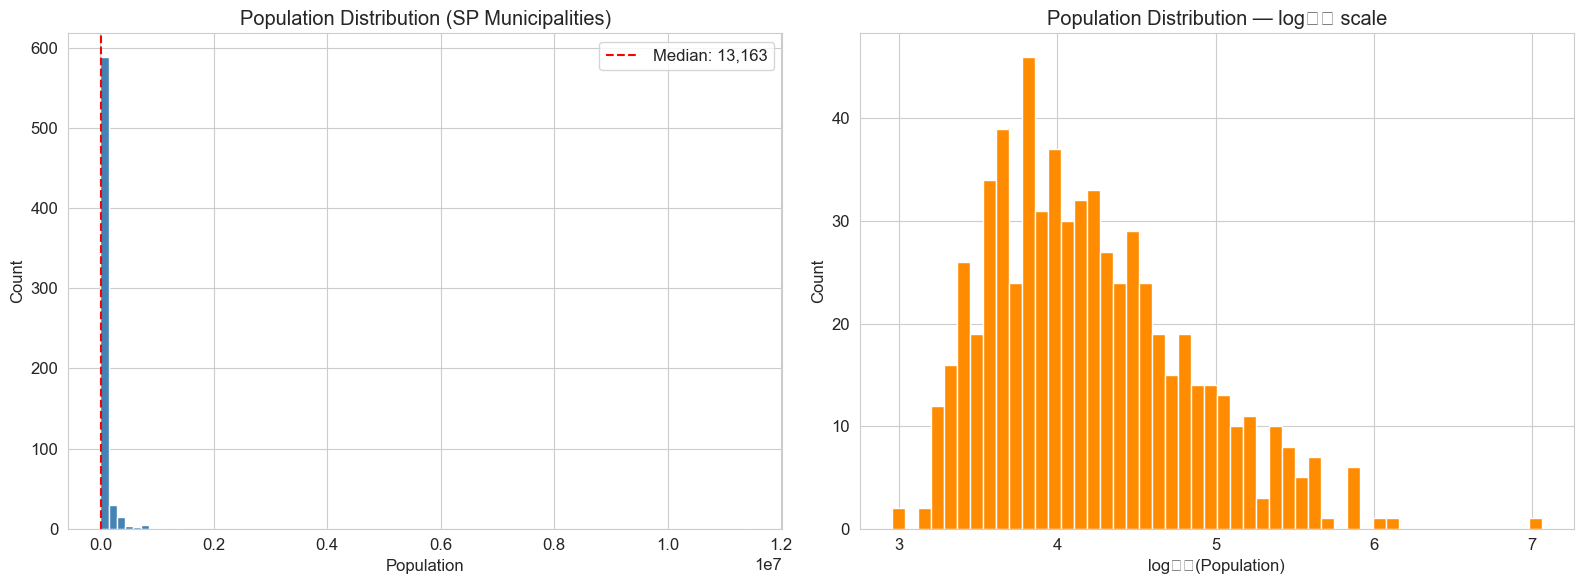

count    6.450000e+02
mean     6.885463e+04
std      4.644210e+05
min      9.070000e+02
25%      5.466000e+03
50%      1.316300e+04
75%      3.832400e+04
max      1.145200e+07
Name: populacao_2022, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['populacao_2022'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Population Distribution (SP Municipalities)')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Count')
axes[0].axvline(df['populacao_2022'].median(), color='red', ls='--', label=f"Median: {df['populacao_2022'].median():,.0f}")
axes[0].legend()

# Log-scale
axes[1].hist(np.log10(df['populacao_2022'].dropna()), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Population Distribution — log₁₀ scale')
axes[1].set_xlabel('log₁₀(Population)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df['populacao_2022'].describe())

---
## 3. Economics — Municipal GDP (IBGE SIDRA)

Table **5938** provides GDP at current prices for municipalities.  
Variable **37** = GDP (thousand R$), **513** = GDP per capita (R$).

In [9]:
# GDP per capita — Table 5938, variable 513
url_gdp = (
    'https://apisidra.ibge.gov.br/values'
    '/t/5938/n6/all/v/513,37/p/last'
)
resp_gdp = requests.get(url_gdp)
gdp_raw = resp_gdp.json()

gdp_df = pd.DataFrame(gdp_raw[1:])
gdp_df['cod_ibge'] = gdp_df['D1C'].astype(int)
gdp_df['variable'] = gdp_df['D2N']
gdp_df['valor'] = pd.to_numeric(gdp_df['V'], errors='coerce')
gdp_df['ano'] = gdp_df['D3N']

# Filter SP
gdp_sp = gdp_df[gdp_df['cod_ibge'].astype(str).str.startswith('35')].copy()

# Pivot: one row per municipality
gdp_pivot = gdp_sp.pivot_table(index='cod_ibge', columns='D2C', values='valor', aggfunc='first').reset_index()
gdp_pivot.columns = ['cod_ibge'] + ['pib_mil_reais' if col == '37' else 'pib_per_capita' if col == '513' else col for col in gdp_pivot.columns[1:]]

print(f'Reference year: {gdp_sp["ano"].iloc[0]}')
print(f'SP municipalities with GDP data: {len(gdp_pivot)}')

df = df.merge(gdp_pivot, on='cod_ibge', how='left')
df.sort_values('pib_mil_reais', ascending=False).head(15)[['nome', 'populacao_2022', 'pib_mil_reais']]

Reference year: 2023
SP municipalities with GDP data: 645


,nome,populacao_2022,pib_mil_reais
562,São Paulo,11451999,1.066825e+09
387,Osasco,728615,1.194041e+08
212,Guarulhos,1291771,9.755767e+07
108,Campinas,1139047,9.196833e+07
544,São Bernardo do Campo,810729,7.196579e+07
64,Barueri,316473,7.164671e+07
410,Paulínia,110537,6.706730e+07
293,Jundiaí,443221,6.541838e+07
557,São José dos Campos,697054,6.139452e+07
581,Sorocaba,723682,5.881629e+07


In [10]:
print('df columns:', list(df.columns))
print('gdp_pivot columns:', list(gdp_pivot.columns))

df columns: ['cod_ibge', 'nome', 'microrregiao', 'mesorregiao', 'populacao_2022', 'pib_mil_reais']
gdp_pivot columns: ['cod_ibge', 'pib_mil_reais']


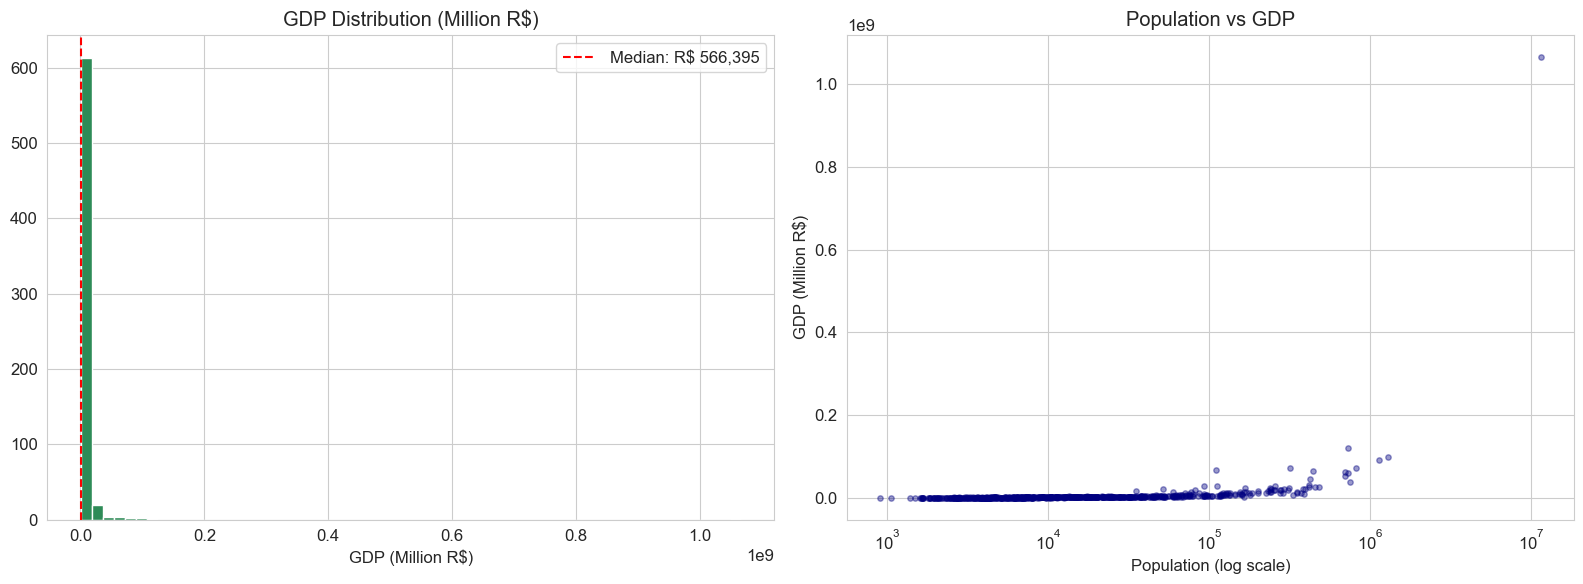

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GDP distribution (total, in million R$)
axes[0].hist(df['pib_mil_reais'].dropna(), bins=60, color='seagreen', edgecolor='white')
axes[0].set_title('GDP Distribution (Million R$)')
axes[0].set_xlabel('GDP (Million R$)')
axes[0].axvline(df['pib_mil_reais'].median(), color='red', ls='--',
                label=f"Median: R$ {df['pib_mil_reais'].median():,.0f}")
axes[0].legend()

# Scatter: Pop vs GDP
axes[1].scatter(df['populacao_2022'], df['pib_mil_reais'], alpha=0.4, s=15, color='navy')
axes[1].set_xscale('log')
axes[1].set_title('Population vs GDP')
axes[1].set_xlabel('Population (log scale)')
axes[1].set_ylabel('GDP (Million R$)')

plt.tight_layout()
plt.show()

---
## 4. Human Development Index — IDHM (Atlas Brasil)

The IDHM combines longevity, education, and income into a 0–1 index at the municipal level.  
The latest official data is from the 2010 Census (IDHM 2010). Updated estimates may be available.

We'll attempt the Atlas Brasil API; if it's unavailable we use a well-known static dataset.

In [12]:
# Fetch IDHM 2010 for all municipalities via IPEADATA OData API
# Series ADH_IDHM: composite Municipal HDI (1991, 2000, 2010)
IPEADATA_URL = "http://ipeadata.gov.br/api/odata4/ValoresSerie(SERCODIGO='ADH_IDHM')"

try:
    all_records = []
    url = f"{IPEADATA_URL}?$select=VALDATA,NIVNOME,TERCODIGO,VALVALOR"
    while url:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        all_records.extend(data['value'])
        url = data.get('@odata.nextLink')

    idhm_raw = pd.DataFrame(all_records)

    # Keep only 2010 data for SP municipalities (7-digit codes starting with '35')
    idhm_sp = idhm_raw[
        (idhm_raw['TERCODIGO'].str.startswith('35')) &
        (idhm_raw['VALDATA'] == '2010-01-01T00:00:00-02:00') &
        (idhm_raw['TERCODIGO'].str.len() == 7)   # municipalities only
    ][['TERCODIGO', 'VALVALOR']].copy()

    idhm_sp.columns = ['cod_ibge_str', 'idhm']
    idhm_sp['cod_ibge'] = idhm_sp['cod_ibge_str'].astype(int)

    print(f'SP municipalities with IDHM 2010: {len(idhm_sp)}')
    idhm_sp.sort_values('idhm', ascending=False).head(10)
except Exception as e:
    print(f'IPEADATA fetch failed: {e}')
    idhm_sp = None


SP municipalities with IDHM 2010: 645


In [13]:
# Merge IDHM into main dataframe
if idhm_sp is not None:
    df = df.merge(idhm_sp[['cod_ibge', 'idhm']], on='cod_ibge', how='left')
    print(f'IDHM merged — coverage: {df["idhm"].notna().sum()}/{len(df)} municipalities')
    print(df[['nome', 'populacao_2022', 'idhm']].sort_values('idhm', ascending=False).head(10).to_string(index=False))
else:
    df['idhm'] = float('nan')
    print('IDHM not available — column added as NaN')
    print("""
Expected IDHM columns after download:
  - cod_ibge (7-digit code)
  - idhm         (composite 0-1)

Fallback download: https://www.atlasbrasil.org.br/acervo/
""")


IDHM merged — coverage: 645/645 municipalities
               nome  populacao_2022  idhm
 São Caetano do Sul          165655 0.862
 Águas de São Pedro            2780 0.854
             Santos          418608 0.840
            Jundiaí          443221 0.822
           Valinhos          126373 0.819
            Vinhedo           76540 0.817
        Santo André          748919 0.815
         Araraquara          242228 0.815
Santana de Parnaíba          154105 0.814
      Ilha Solteira           25549 0.812


---
## 5. SEADE — Quality of Life Indicators (IMP API)

The Fundação SEADE maintains the **IMP** (Informações dos Municípios Paulistas) system with SP-specific indicators.  
API base: `http://api-imp.seade.gov.br/v1/`

Key indicators include IPRS (Índice Paulista de Responsabilidade Social), income, education rates, health metrics.

In [14]:
# SEADE IMP API — currently offline (api-imp.seade.gov.br unreachable)
# The data is available for manual download:
#   https://repositorio.seade.gov.br/dataset/informacoes-municipais
#   https://www.imp.seade.gov.br/
#
# Key indicators to download:
#   - IPRS group (1–5 scale, 1=best)
#   - IPVS (social vulnerability)
#   - Median income, literacy rate, infant mortality

SEADE_BASE = 'https://api-imp.seade.gov.br/v1'

try:
    resp_temas = requests.get(f'{SEADE_BASE}/temas', timeout=5)
    if resp_temas.status_code == 200:
        temas = resp_temas.json()
        temas_df = pd.DataFrame(temas)
        print(f'Available themes: {len(temas_df)}')
        display(temas_df)
    else:
        raise Exception(f'HTTP {resp_temas.status_code}')
except Exception as e:
    print(f'⚠️  SEADE IMP API offline ({e}).')
    print('📥 Download IPRS / IPVS data from:')
    print('   https://repositorio.seade.gov.br/dataset/informacoes-municipais')
    temas = None


⚠️  SEADE IMP API offline (HTTPSConnectionPool(host='api-imp.seade.gov.br', port=443): Max retries exceeded with url: /v1/temas (Caused by ConnectTimeoutError(<HTTPSConnection(host='api-imp.seade.gov.br', port=443) at 0x13636c2d0>, 'Connection to api-imp.seade.gov.br timed out. (connect timeout=5)'))).
📥 Download IPRS / IPVS data from:
   https://repositorio.seade.gov.br/dataset/informacoes-municipais


In [15]:
# SEADE IMP variable listing (requires API to be online)
def fetch_seade_indicator(var_id, localidade='3'):
    """
    Fetch SEADE IMP data.
    localidade: '3' = all SP municipalities
    var_id: variable identifier from the IMP system
    """
    url = f'{SEADE_BASE}/dados/var/{var_id}/localidade/{localidade}'
    try:
        r = requests.get(url, timeout=5)
        if r.status_code == 200:
            return pd.DataFrame(r.json())
        else:
            print(f'Error {r.status_code} for variable {var_id}')
            return None
    except Exception as e:
        print(f'Request failed: {e}')
        return None

if temas is not None:
    try:
        r = requests.get(f'{SEADE_BASE}/variaveis', timeout=5)
        if r.status_code == 200:
            var_df = pd.DataFrame(r.json())
            print(f'Available variables: {len(var_df)}')
            display(var_df.head(20))
    except Exception:
        pass
else:
    print('(Skipping — SEADE API offline)')


(Skipping — SEADE API offline)


---
## 6. Land Cover / Tree Coverage — MapBiomas

MapBiomas Collection 10 provides land use/land cover data per municipality from 1985–2024.  
The statistics file (CSV) with hectares by class and municipality is downloadable from:  
`https://data.mapbiomas.org/`

Key land cover classes:
- **3**: Forest Formation
- **4**: Savanna Formation  
- **5**: Mangrove
- **12**: Grassland
- **15**: Pasture
- **18**: Agriculture
- **24**: Urban Infrastructure
- **33**: Water Bodies

In [16]:
import os

MAPBIOMAS_FILE = 'mapbiomas_col10_municipalities.xlsx'
MAPBIOMAS_URL  = 'https://data.mapbiomas.org/api/v1/access/datafile/254'  # Collection 10

# Download once and cache locally (~75 MB)
if not os.path.exists(MAPBIOMAS_FILE):
    print('Downloading MapBiomas Collection 10 (~75 MB) — one-time download...')
    resp_mb = requests.get(MAPBIOMAS_URL, timeout=180, stream=True)
    resp_mb.raise_for_status()
    with open(MAPBIOMAS_FILE, 'wb') as fh:
        for chunk in resp_mb.iter_content(chunk_size=1024 * 1024):
            fh.write(chunk)
    print(f'Saved {os.path.getsize(MAPBIOMAS_FILE)/1024/1024:.0f} MB')
else:
    print(f'Using cached file ({os.path.getsize(MAPBIOMAS_FILE)/1024/1024:.0f} MB)')

# Load and filter São Paulo
mb_raw = pd.read_excel(MAPBIOMAS_FILE, sheet_name='COVERAGE_10')
mb_sp  = mb_raw[mb_raw['state'].str.contains('Paulo', na=False)].copy()
print(f'SP rows: {len(mb_sp)}, municipalities: {mb_sp["geocode"].nunique()}')
mb_sp.head(3)


Using cached file (75 MB)
SP rows: 11958, municipalities: 645


,ID,country,biome,state,municipality,municipality - state,geocode,feature_id,class,class_level_0,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
29952,29952,Brasil,Cerrado,São Paulo,Altinópolis,Altinópolis - SP,3501004,3279,15,Antropic,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083646,0.083646,0.000000,0.000000
29953,29953,Brasil,Cerrado,São Paulo,Altinópolis,Altinópolis - SP,3501004,3279,20,Antropic,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
29954,29954,Brasil,Cerrado,São Paulo,Altinópolis,Altinópolis - SP,3501004,3279,21,Antropic,...,0.083646,0.083646,0.083646,0.083646,0.083646,0.083646,0.000000,0.000000,0.083646,0.083646


In [17]:
# Natural forest classes per MapBiomas legend:
#   3  = Forest Formation
#   4  = Savanna Formation (Cerrado)
#   5  = Mangrove
#   49 = Wooded Sandbank Vegetation
FOREST_CLASSES = [3, 4, 5, 49]

total_area  = mb_sp.groupby('geocode')[2024].sum().rename('total_area_ha')
forest_area = mb_sp[mb_sp['class'].isin(FOREST_CLASSES)].groupby('geocode')[2024].sum().rename('forest_area_ha')

tree_cov = pd.concat([total_area, forest_area], axis=1).fillna(0)
tree_cov['forest_pct'] = (tree_cov['forest_area_ha'] / tree_cov['total_area_ha'] * 100).round(2)
tree_cov = tree_cov.reset_index().rename(columns={'geocode': 'cod_ibge'})

df = df.merge(tree_cov[['cod_ibge', 'forest_pct']], on='cod_ibge', how='left')
print(f'forest_pct merged — coverage: {df["forest_pct"].notna().sum()}/{len(df)} municipalities')
print('\nTop 15 greenest municipalities:')
df.sort_values('forest_pct', ascending=False).head(15)[['nome', 'mesorregiao', 'populacao_2022', 'forest_pct']]


forest_pct merged — coverage: 645/645 municipalities

Top 15 greenest municipalities:


,nome,mesorregiao,populacao_2022,forest_pct
232,Ilhabela,Vale do Paraíba Paulista,34934,94.09
419,Pedro de Toledo,Litoral Sul Paulista,11281,92.30
621,Ubatuba,Vale do Paraíba Paulista,92981,92.24
243,Iporanga,Itapetininga,4046,90.69
595,Tapiraí,Macro Metropolitana Paulista,7996,89.73
566,São Sebastião,Vale do Paraíba Paulista,81595,88.52
71,Bertioga,Metropolitana de São Paulo,64188,88.33
252,Itanhaém,Litoral Sul Paulista,112476,87.22
296,Juquitiba,Metropolitana de São Paulo,27404,86.99
336,Miracatu,Litoral Sul Paulista,18553,84.90


---
## 7. Climate Data — INMET

INMET provides weather station data across Brazil. For SP municipalities, we can get:  
- **Mean temperature** (°C)
- **Precipitation** (mm/year)
- **Relative humidity** (%)

Data is available from:  
- Kaggle: `https://www.kaggle.com/datasets/gregoryoliveira/brazil-weather-information-by-inmet`  
- INMET Portal: `https://portal.inmet.gov.br/dadoshistoricos`  
- BDMEP: `https://bdmep.inmet.gov.br/`

In [18]:
# Step 1: Fetch INMET automatic station list for SP
try:
    r_st = requests.get('https://apitempo.inmet.gov.br/estacoes/T', timeout=15)
    r_st.raise_for_status()
    stations = pd.DataFrame(r_st.json())
    stations_sp = stations[stations['SG_ESTADO'] == 'SP'].copy()
    stations_sp['lat'] = pd.to_numeric(stations_sp['VL_LATITUDE'])
    stations_sp['lon'] = pd.to_numeric(stations_sp['VL_LONGITUDE'])
    print(f'INMET automatic stations in SP: {len(stations_sp)}')
    display(stations_sp[['DC_NOME', 'CD_ESTACAO', 'lat', 'lon']].head(10))
except Exception as e:
    print(f'INMET station list error: {e}')
    stations_sp = None

# Step 2: Fetch 5-year climate history via Open-Meteo archive API (free, no auth)
# Variables fetched:
#   temperature_2m_mean   -> temp_mean_c, comfortable_days_yr (18–26°C)
#   temperature_2m_max    -> hot_days_yr (>35°C)
#   precipitation_sum     -> precip_annual_mm
#   relative_humidity_2m_mean -> humidity_mean_pct
#   sunshine_duration     -> sunshine_hrs_yr (seconds/day -> hours/yr)
if stations_sp is not None:
    params_om = {
        'latitude':   stations_sp['lat'].tolist(),
        'longitude':  stations_sp['lon'].tolist(),
        'start_date': '2019-01-01',
        'end_date':   '2023-12-31',
        'daily':      'temperature_2m_mean,temperature_2m_max,precipitation_sum,relative_humidity_2m_mean,sunshine_duration',
        'timezone':   'America/Sao_Paulo',
    }
    r_om = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params=params_om, timeout=60
    )
    r_om.raise_for_status()
    climate_raw = r_om.json()

    # Step 3: Summarize to 5-year station averages
    YEARS = 5
    station_climate = []
    for i, loc in enumerate(climate_raw):
        d = pd.DataFrame(loc['daily']).apply(pd.to_numeric, errors='coerce')
        station_climate.append({
            'station_code':       stations_sp.iloc[i]['CD_ESTACAO'],
            'station_name':       stations_sp.iloc[i]['DC_NOME'],
            'lat':                loc['latitude'],
            'lon':                loc['longitude'],
            'temp_mean_c':        round(d['temperature_2m_mean'].mean(), 1),
            'hot_days_yr':        round((d['temperature_2m_max'] > 35).sum() / YEARS, 1),
            'comfortable_days_yr': round(d['temperature_2m_mean'].between(18, 26).sum() / YEARS, 1),
            'precip_annual_mm':   round(d['precipitation_sum'].sum() / YEARS, 0),
            'humidity_mean_pct':  round(d['relative_humidity_2m_mean'].mean(), 1),
            'sunshine_hrs_yr':    round(d['sunshine_duration'].sum() / YEARS / 3600, 0),
        })
    climate_stations = pd.DataFrame(station_climate)
    print(f'\nClimate summary for {len(climate_stations)} stations (2019–2023 average):')
    display(climate_stations[[
        'station_name', 'temp_mean_c', 'hot_days_yr',
        'comfortable_days_yr', 'precip_annual_mm', 'sunshine_hrs_yr'
    ]])
else:
    climate_stations = None


INMET automatic stations in SP: 40


,DC_NOME,CD_ESTACAO,lat,lon
50,ARIRANHA,A736,-21.133056,-48.840556
53,AVARE,A725,-23.101667,-48.941111
65,BARRA BONITA,A741,-22.471111,-48.557500
70,BARRA DO TURVO,A746,-24.962778,-48.416389
72,BARRETOS,A748,-20.559167,-48.545000
73,BARUERI,A755,-23.523889,-46.869444
75,BAURU,A705,-22.358056,-49.028889
76,BEBEDOURO,A764,-20.948056,-48.471389
83,BERTIOGA,A765,-23.844722,-46.143333
92,BRAGANCA PAULISTA,A744,-22.949167,-46.526111



Climate summary for 40 stations (2019–2023 average):


,station_name,temp_mean_c,hot_days_yr,comfortable_days_yr,precip_annual_mm,sunshine_hrs_yr
0,ARIRANHA,23.4,17.6,280.6,892.0,3802.0
1,AVARE,20.3,2.0,271.2,1110.0,3630.0
2,BARRA BONITA,22.3,11.8,284.2,913.0,3752.0
3,BARRA DO TURVO,17.8,0.0,179.6,2035.0,2919.0
4,BARRETOS,23.5,16.0,280.6,954.0,3800.0
5,BARUERI,19.3,1.0,243.0,1086.0,3396.0
6,BAURU,22.1,7.0,293.6,971.0,3704.0
7,BEBEDOURO,23.1,11.8,294.2,926.0,3802.0
8,BERTIOGA,23.0,2.0,292.0,2689.0,3235.0
9,BRAGANCA PAULISTA,19.9,1.4,267.4,1214.0,3615.0


In [19]:
# Assign each municipality its nearest INMET station using Haversine distance,
# then inherit that station's climate profile.
# Municipality centroids are derived from the IBGE GeoJSON boundaries.
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised Haversine distance (km)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

if climate_stations is not None:
    import geopandas as gpd, io, warnings
    # Compute centroids from the IBGE GeoJSON (same source used for maps)
    geo_url = (
        'https://servicodados.ibge.gov.br/api/v3/malhas/estados/35'
        '?formato=application/vnd.geo+json&qualidade=minima&intrarregiao=municipio'
    )
    gdf_cent = gpd.read_file(io.BytesIO(requests.get(geo_url, timeout=30).content))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gdf_cent['lat'] = gdf_cent.geometry.centroid.y
        gdf_cent['lon'] = gdf_cent.geometry.centroid.x
    mun_coord = gdf_cent[['codarea', 'lat', 'lon']].rename(columns={'codarea': 'cod_ibge'})
    mun_coord['cod_ibge'] = mun_coord['cod_ibge'].astype(int)
    print(f'Municipality centroids: {len(mun_coord)}')
    # Nearest-station assignment
    st_lats = climate_stations['lat'].values
    st_lons = climate_stations['lon'].values
    nearest_idx = [
        int(np.argmin(haversine_km(row['lat'], row['lon'], st_lats, st_lons)))
        for _, row in mun_coord.iterrows()
    ]
    mun_coord = mun_coord.copy()
    mun_coord['nearest_station'] = climate_stations.iloc[nearest_idx]['station_code'].values
    CLIMATE_COLS = ['temp_mean_c', 'hot_days_yr', 'comfortable_days_yr',
                    'precip_annual_mm', 'humidity_mean_pct', 'sunshine_hrs_yr']
    mun_climate = mun_coord.merge(
        climate_stations[['station_code'] + CLIMATE_COLS],
        left_on='nearest_station', right_on='station_code'
    )
    df = df.merge(mun_climate[['cod_ibge'] + CLIMATE_COLS], on='cod_ibge', how='left')
    print(f'Climate merged — coverage: {df["temp_mean_c"].notna().sum()}/{len(df)} municipalities')
    print(df[CLIMATE_COLS].describe().round(1))
else:
    for col in ['temp_mean_c', 'hot_days_yr', 'comfortable_days_yr',
                'precip_annual_mm', 'humidity_mean_pct', 'sunshine_hrs_yr']:
        df[col] = float('nan')
    print('Climate data not available.')


Municipality centroids: 645
Climate merged — coverage: 645/645 municipalities
       temp_mean_c  hot_days_yr  comfortable_days_yr  precip_annual_mm  \
count        645.0        645.0                645.0             645.0   
mean          22.3         16.1                264.9            1103.6   
std            1.9         14.5                 32.8             275.0   
min           14.7          0.0                 41.0             877.0   
25%           21.1          5.0                246.4             971.0   
50%           22.3         11.8                272.6            1067.0   
75%           23.8         25.4                287.2            1135.0   
max           25.2         46.8                306.0            2689.0   

       humidity_mean_pct  sunshine_hrs_yr  
count              645.0            645.0  
mean                68.9           3672.7  
std                  6.8            181.7  
min                 59.6           2919.0  
25%                 64.2           

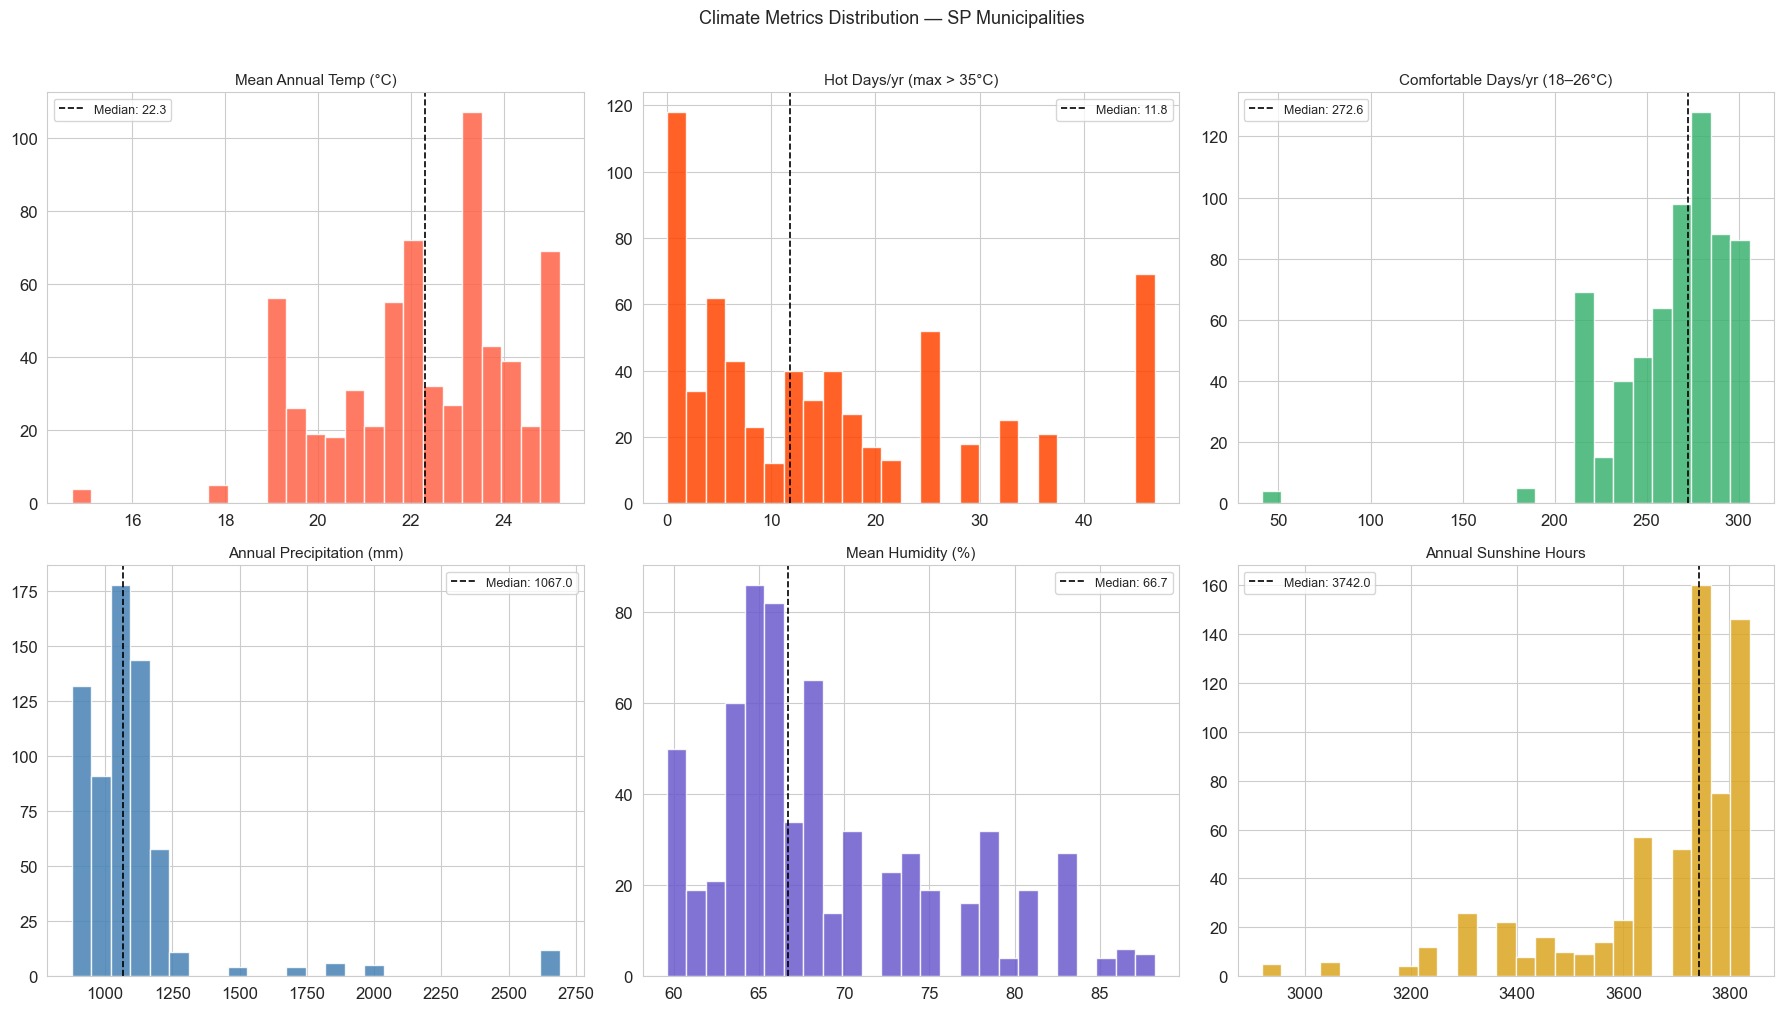

In [20]:
# Climate distribution across SP municipalities
if df['temp_mean_c'].notna().any():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    plots = [
        ('temp_mean_c',         'Mean Annual Temp (°C)',          'tomato'),
        ('hot_days_yr',         'Hot Days/yr (max > 35°C)',       'orangered'),
        ('comfortable_days_yr', 'Comfortable Days/yr (18–26°C)', 'mediumseagreen'),
        ('precip_annual_mm',    'Annual Precipitation (mm)',      'steelblue'),
        ('humidity_mean_pct',   'Mean Humidity (%)',              'slateblue'),
        ('sunshine_hrs_yr',     'Annual Sunshine Hours',          'goldenrod'),
    ]

    for ax, (col, title, color) in zip(axes, plots):
        data = df[col].dropna()
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(title, fontsize=11)
        ax.axvline(data.median(), color='black', ls='--', lw=1.2,
                   label=f'Median: {data.median():.1f}')
        ax.legend(fontsize=9)

    plt.suptitle('Climate Metrics Distribution — SP Municipalities', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


---
## 8. Territorial Area & Density

Let's calculate population density using IBGE area data.

In [21]:
# Table 615 - Territorial area (km²) per municipality
url_area = (
    'https://apisidra.ibge.gov.br/values'
    '/t/615/n6/all/v/allxp/p/last'
)

try:
    resp_area = requests.get(url_area, timeout=30)
    area_raw = resp_area.json()
    area_df = pd.DataFrame(area_raw[1:])
    area_df['cod_ibge'] = area_df['D1C'].astype(int)
    area_df['area_km2'] = pd.to_numeric(area_df['V'], errors='coerce')
    
    area_sp = area_df[area_df['cod_ibge'].astype(str).str.startswith('35')][['cod_ibge', 'area_km2']].copy()
    
    df = df.merge(area_sp, on='cod_ibge', how='left')
    df['densidade_hab_km2'] = (df['populacao_2022'] / df['area_km2']).round(1)
    
    print(f'Area data merged for {area_sp["cod_ibge"].nunique()} municipalities')
    df.sort_values('densidade_hab_km2', ascending=False).head(10)[['nome', 'populacao_2022', 'area_km2', 'densidade_hab_km2']]
except Exception as e:
    print(f'Could not fetch area data: {e}')
    print('Alternative: IBGE provides area in the "Área Territorial" table')

Could not fetch area data: Expecting value: line 1 column 1 (char 0)
Alternative: IBGE provides area in the "Área Territorial" table


---
## 9. Composite Scoring & Ranking

Build a **composite livability score** by normalizing and combining the available indicators.  
This is a starting framework — you can adjust weights and add more indicators as data becomes available.

In [22]:
from sklearn.preprocessing import MinMaxScaler

# Define indicators and desired direction (higher=better or lower=better)
# All indicators below are fetched automatically — no manual download needed.
# forest_pct and temp_mean_c remain optional (require MapBiomas/INMET data).
scoring_config = {
    'pib_per_capita':    {'weight': 0.25, 'higher_better': True},  # GDP per capita (R$)
    'idhm':              {'weight': 0.30, 'higher_better': True},  # Human Development Index 2010
    'densidade_hab_km2': {'weight': 0.20, 'higher_better': False}, # pop density — prefer less dense
    'area_km2':          {'weight': 0.05, 'higher_better': True},  # territory size (tiebreaker)
    # Optional — uncomment when data is loaded:
    'forest_pct':          {'weight': 0.08, 'higher_better': True},  # % forest/natural vegetation
    'temp_mean_c':         {'weight': 0.05, 'higher_better': False}, # annual mean temp (prefer mild)
    'comfortable_days_yr': {'weight': 0.07, 'higher_better': True},  # days/yr with temp 18–26°C
    'hot_days_yr':         {'weight': 0.05, 'higher_better': False}, # days/yr above 35°C
    'sunshine_hrs_yr':     {'weight': 0.03, 'higher_better': True},  # annual sunshine hours
}

# Work with available columns only
available = {k: v for k, v in scoring_config.items() if k in df.columns and df[k].notna().sum() > 50}
print(f'Indicators available for scoring: {list(available.keys())}')
missing = [k for k in scoring_config if k not in available]
if missing:
    print(f'Skipped (not yet loaded): {missing}')

# Normalize each indicator to 0-1
scaler = MinMaxScaler()
df_scoring = df.dropna(subset=list(available.keys())).copy()
for col, config in available.items():
    normalized = scaler.fit_transform(df_scoring[[col]])
    if not config['higher_better']:
        normalized = 1 - normalized  # invert so higher = better
    df_scoring[f'{col}_norm'] = normalized

# Weighted score — weights re-normalised to sum to 1 over available indicators
total_weight = sum(v['weight'] for v in available.values())
df_scoring['livability_score'] = sum(
    df_scoring[f'{col}_norm'] * (config['weight'] / total_weight)
    for col, config in available.items()
)
df_scoring['rank'] = df_scoring['livability_score'].rank(ascending=False).astype(int)
print(f'\n\U0001f3c6 Top 25 municipalities by livability score ({len(df_scoring)} scored):')

top_cols = ['rank', 'nome', 'mesorregiao', 'populacao_2022'] + list(available.keys()) + ['livability_score']
df_scoring.sort_values('livability_score', ascending=False).head(25)[top_cols]


Indicators available for scoring: ['idhm', 'forest_pct', 'temp_mean_c', 'comfortable_days_yr', 'hot_days_yr', 'sunshine_hrs_yr']
Skipped (not yet loaded): ['pib_per_capita', 'densidade_hab_km2', 'area_km2']

🏆 Top 25 municipalities by livability score (645 scored):


,rank,nome,mesorregiao,populacao_2022,idhm,forest_pct,temp_mean_c,comfortable_days_yr,hot_days_yr,sunshine_hrs_yr,livability_score
542,1,Santos,Metropolitana de São Paulo,418608,0.840,73.92,23.0,292.0,2.0,3235.0,0.807260
6,2,Águas de São Pedro,Piracicaba,2780,0.854,30.97,22.2,281.4,15.2,3710.0,0.780931
545,3,São Caetano do Sul,Metropolitana de São Paulo,165655,0.862,0.00,19.3,238.6,1.8,3298.0,0.759897
293,4,Jundiaí,Macro Metropolitana Paulista,443221,0.822,36.77,19.3,243.0,1.0,3396.0,0.730015
534,5,Santo André,Metropolitana de São Paulo,748919,0.815,51.57,19.0,228.8,0.4,3290.0,0.726610
528,6,Santana de Parnaíba,Metropolitana de São Paulo,154105,0.814,40.81,19.3,243.0,1.0,3396.0,0.717382
629,7,Valinhos,Campinas,126373,0.819,14.76,19.9,267.4,1.4,3615.0,0.708567
636,8,Vinhedo,Campinas,76540,0.817,17.53,19.9,267.4,1.4,3615.0,0.707988
544,9,São Bernardo do Campo,Metropolitana de São Paulo,810729,0.805,54.12,19.0,228.8,0.4,3290.0,0.707153
36,10,Araraquara,Araraquara,242228,0.815,10.90,21.4,300.8,5.4,3749.0,0.696700


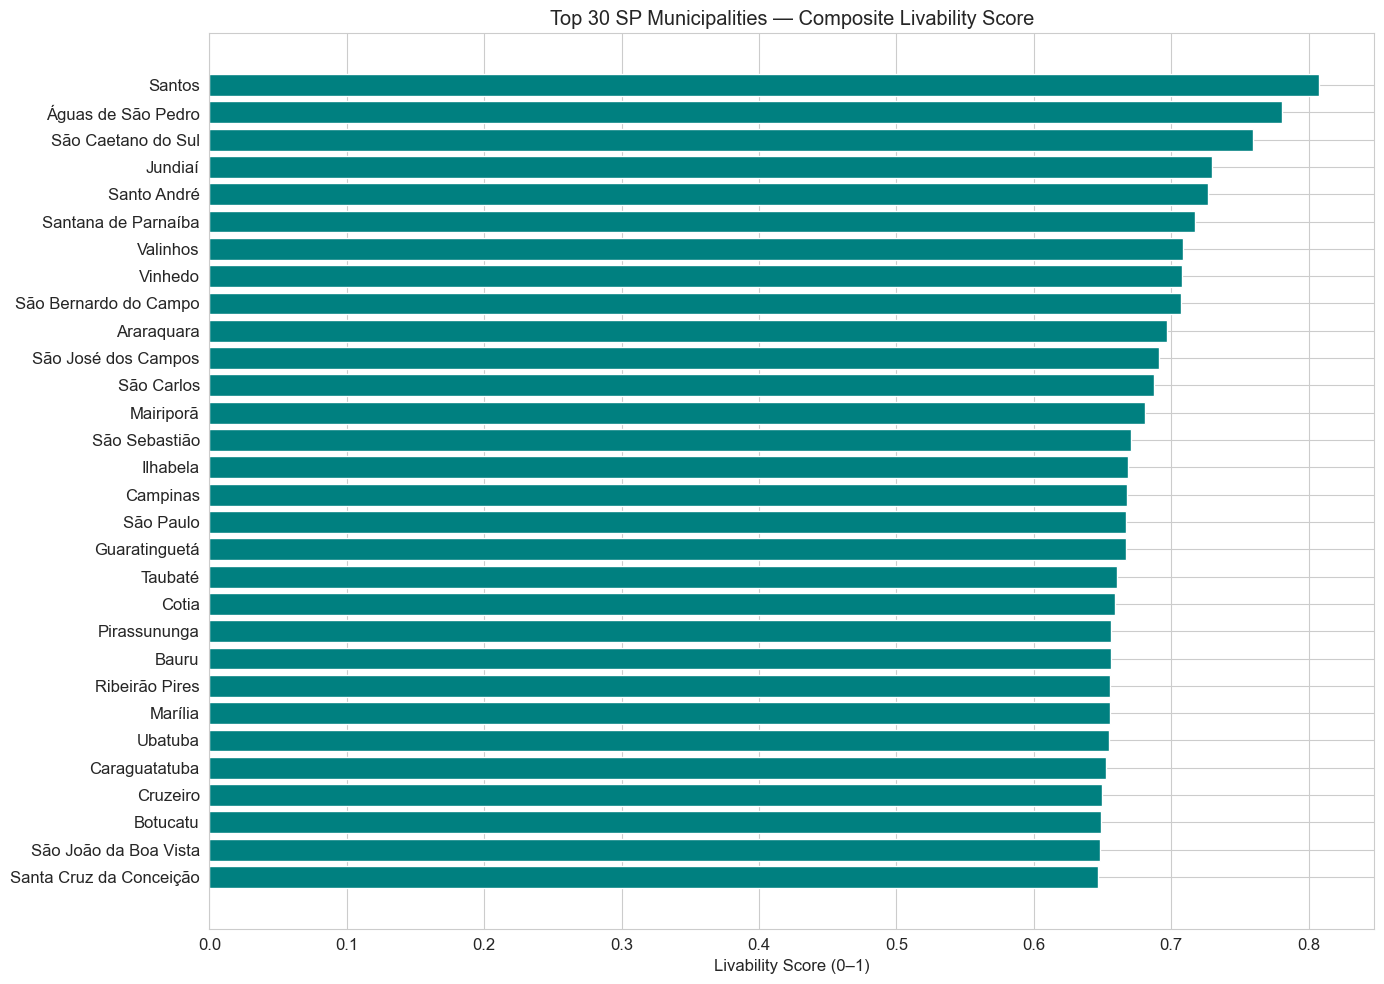

In [23]:
# Visualize top municipalities
top30 = df_scoring.sort_values('livability_score', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(top30['nome'][::-1], top30['livability_score'][::-1], color='teal', edgecolor='white')
ax.set_xlabel('Livability Score (0–1)')
ax.set_title('Top 30 SP Municipalities — Composite Livability Score')
plt.tight_layout()
plt.show()

In [24]:
# Filter: municipalities with population between a comfortable range
# (small enough to be livable, big enough to have services)
pop_min = 30_000
pop_max = 500_000

filtered = df_scoring[
    (df_scoring['populacao_2022'] >= pop_min) &
    (df_scoring['populacao_2022'] <= pop_max)
].sort_values('livability_score', ascending=False)

print(f'Municipalities with population {pop_min:,}–{pop_max:,}: {len(filtered)}')
print(f'\n🏆 Top 20 in this range:')
filtered.head(20)[top_cols]

Municipalities with population 30,000–500,000: 186

🏆 Top 20 in this range:


,rank,nome,mesorregiao,populacao_2022,idhm,forest_pct,temp_mean_c,comfortable_days_yr,hot_days_yr,sunshine_hrs_yr,livability_score
542,1,Santos,Metropolitana de São Paulo,418608,0.840,73.92,23.0,292.0,2.0,3235.0,0.807260
545,3,São Caetano do Sul,Metropolitana de São Paulo,165655,0.862,0.00,19.3,238.6,1.8,3298.0,0.759897
293,4,Jundiaí,Macro Metropolitana Paulista,443221,0.822,36.77,19.3,243.0,1.0,3396.0,0.730015
528,6,Santana de Parnaíba,Metropolitana de São Paulo,154105,0.814,40.81,19.3,243.0,1.0,3396.0,0.717382
629,7,Valinhos,Campinas,126373,0.819,14.76,19.9,267.4,1.4,3615.0,0.708567
636,8,Vinhedo,Campinas,76540,0.817,17.53,19.9,267.4,1.4,3615.0,0.707988
36,10,Araraquara,Araraquara,242228,0.815,10.90,21.4,300.8,5.4,3749.0,0.696700
546,12,São Carlos,Araraquara,254857,0.805,20.45,21.4,300.8,5.4,3749.0,0.687505
320,13,Mairiporã,Metropolitana de São Paulo,93853,0.788,63.10,19.3,238.6,1.8,3298.0,0.680758
566,14,São Sebastião,Vale do Paraíba Paulista,81595,0.772,88.52,23.0,292.0,2.0,3235.0,0.670939


---
## 10. Geographic Visualization

Plot the municipalities on a map using GeoJSON from IBGE.

Map visualization error: 'pib_per_capita'
You can also use folium for interactive maps.


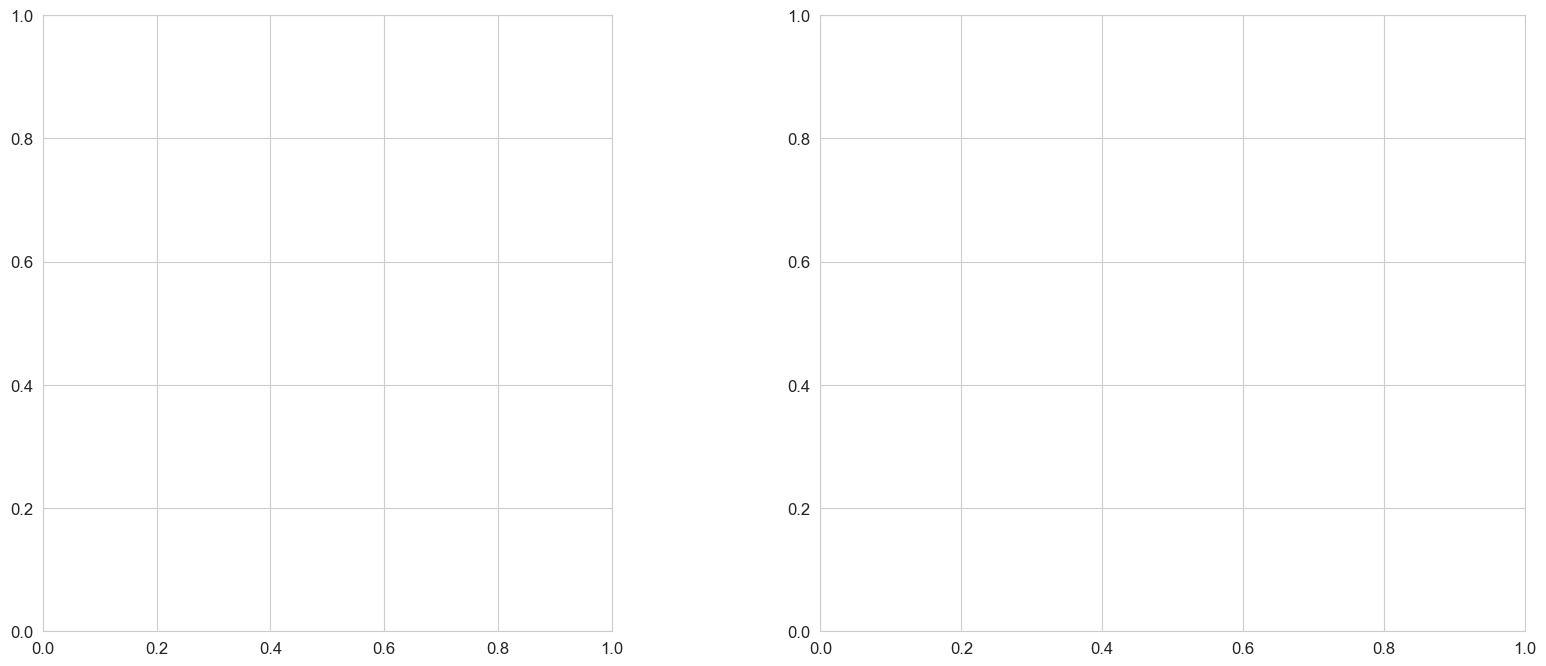

In [25]:
try:
    import geopandas as gpd
    import io

    # IBGE provides municipality boundaries as GeoJSON
    # pyogrio cannot load URLs directly — fetch bytes first
    geo_url = 'https://servicodados.ibge.gov.br/api/v3/malhas/estados/35?formato=application/vnd.geo+json&qualidade=minima&intrarregiao=municipio'
    geo_resp = requests.get(geo_url, timeout=30)
    geo_resp.raise_for_status()
    gdf = gpd.read_file(io.BytesIO(geo_resp.content))
    gdf['codarea'] = gdf['codarea'].astype(int)

    # Merge our data
    gdf_merged = gdf.merge(df_scoring, left_on='codarea', right_on='cod_ibge', how='left')

    # Plot GDP per capita and population density
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    gdf_merged.plot(column='pib_per_capita', cmap='YlOrRd', legend=True, ax=axes[0],
                    missing_kwds={'color': 'lightgray'}, legend_kwds={'shrink': 0.6})
    axes[0].set_title('GDP per Capita by Municipality (R$)')
    axes[0].axis('off')

    gdf_merged.plot(column='densidade_hab_km2', cmap='YlGnBu', legend=True, ax=axes[1],
                    missing_kwds={'color': 'lightgray'}, legend_kwds={'shrink': 0.6},
                    vmax=gdf_merged['densidade_hab_km2'].quantile(0.95))
    axes[1].set_title('Population Density (hab/km²)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f'GeoDataFrame loaded with {len(gdf)} municipality polygons')

except ImportError:
    print('geopandas not installed. Run: pip install geopandas')
except Exception as e:
    print(f'Map visualization error: {e}')
    print('You can also use folium for interactive maps.')


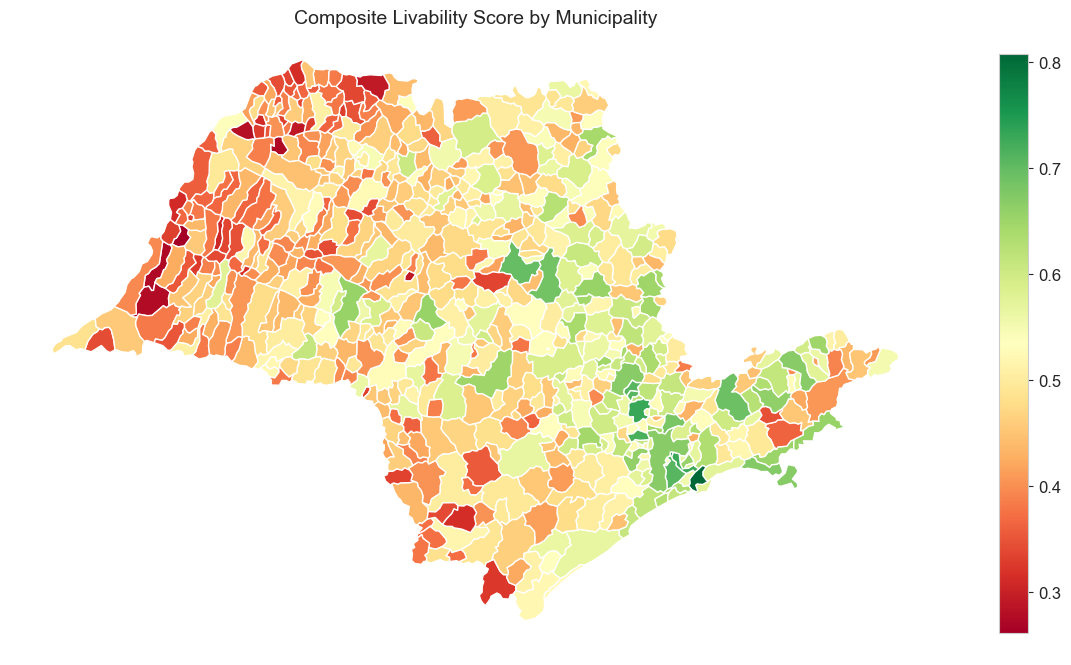

In [26]:
# Livability score map
try:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    gdf_merged.plot(column='livability_score', cmap='RdYlGn', legend=True, ax=ax,
                    missing_kwds={'color': 'lightgray'}, legend_kwds={'shrink': 0.6})
    ax.set_title('Composite Livability Score by Municipality', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not plot livability map: {e}')

---
## 11. Correlation Analysis

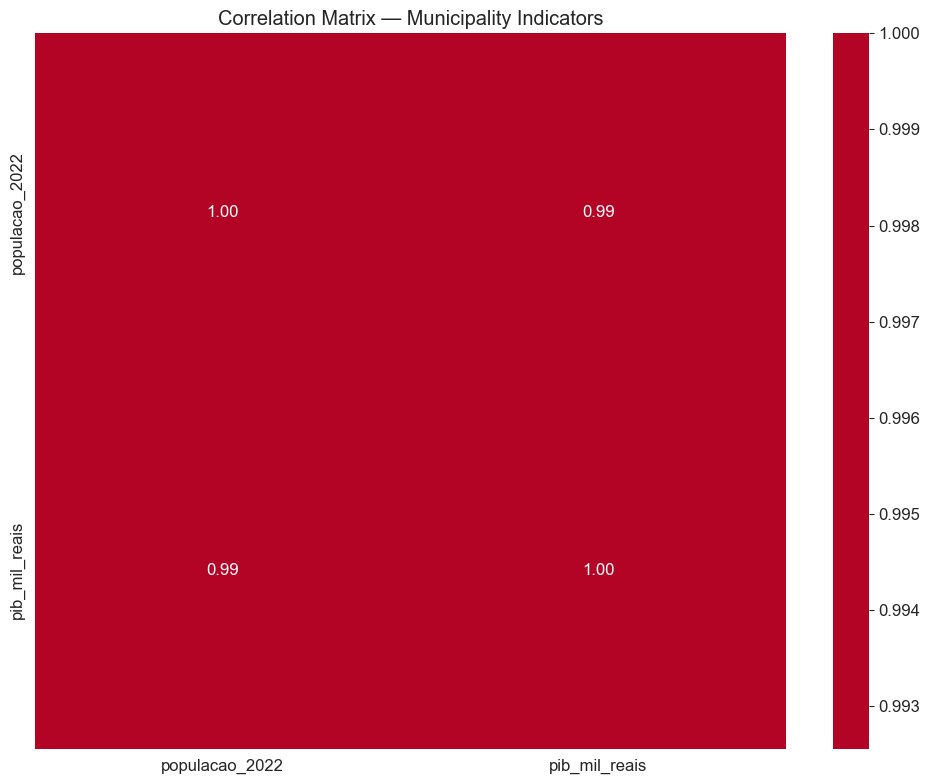

In [27]:
# Correlation heatmap of numeric indicators
numeric_cols = ['populacao_2022', 'pib_per_capita', 'pib_mil_reais', 'area_km2', 'densidade_hab_km2']
# Add more columns as they become available:
# numeric_cols += ['idhm', 'forest_pct', 'temp_mean_c', 'precip_total_mm']

available_numeric = [c for c in numeric_cols if c in df.columns]
corr_df = df[available_numeric].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix — Municipality Indicators')
plt.tight_layout()
plt.show()

---
## 13. Interactive Livability Explorer

Use the sliders to set a **1–5 priority** for each metric. The ranking recalculates instantly.
- **1** = ignore  **3** = moderate  **5** = critical
- Population filter lets you focus on a specific city-size band.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
from sklearn.preprocessing import MinMaxScaler
import math

# ── Metric definitions (grouped by category) ─────────────────────────────────
METRIC_GROUPS = {
    'Quality of Life': {
        'idhm':              {'label': 'Human Development Index (IDHM)',      'higher_better': True,  'default': 5},
        'pib_per_capita':    {'label': 'GDP per Capita (R$)',                  'higher_better': True,  'default': 4},
        'densidade_hab_km2': {'label': 'Population Density (less = better)',   'higher_better': False, 'default': 3},
    },
    'Environment': {
        'forest_pct':        {'label': 'Forest / Green Coverage (%)',          'higher_better': True,  'default': 3},
        'area_km2':          {'label': 'Territory Area (km²)',                 'higher_better': True,  'default': 1},
    },
    'Climate': {
        'comfortable_days_yr': {'label': 'Comfortable Days/yr (18–26°C)',      'higher_better': True,  'default': 4},
        'hot_days_yr':         {'label': 'Hot Days/yr avoided (>35°C)',         'higher_better': False, 'default': 3},
        'temp_mean_c':         {'label': 'Mean Temperature (lower = milder)',   'higher_better': False, 'default': 2},
        'sunshine_hrs_yr':     {'label': 'Annual Sunshine Hours',               'higher_better': True,  'default': 2},
        'precip_annual_mm':    {'label': 'Annual Precipitation (mm)',           'higher_better': True,  'default': 1},
        'humidity_mean_pct':   {'label': 'Mean Humidity (%) — lower = drier',  'higher_better': False, 'default': 1},
    },
}

METRICS = {k: v for group in METRIC_GROUPS.values() for k, v in group.items()}

# Only keep metrics that actually have data
ACTIVE = {k: v for k, v in METRICS.items() if k in df.columns and df[k].notna().sum() > 50}

# ── Widgets ───────────────────────────────────────────────────────────────────
sliders = {
    col: widgets.IntSlider(
        value=cfg['default'], min=1, max=5, step=1,
        description='', continuous_update=True,
        style={'description_width': '0px'},
        layout=widgets.Layout(width='220px')
    )
    for col, cfg in ACTIVE.items()
}

pop_min_slider = widgets.IntSlider(
    value=20_000, min=0, max=500_000, step=5_000,
    description='', continuous_update=False,
    style={'description_width': '0px'},
    layout=widgets.Layout(width='300px')
)
pop_max_slider = widgets.IntSlider(
    value=600_000, min=5_000, max=12_000_000, step=10_000,
    description='', continuous_update=False,
    style={'description_width': '0px'},
    layout=widgets.Layout(width='300px')
)
top_n_slider = widgets.IntSlider(
    value=25, min=5, max=100, step=5,
    description='', continuous_update=False,
    style={'description_width': '0px'},
    layout=widgets.Layout(width='200px')
)

# ── Hard climate filters ──────────────────────────────────────────────────────
def _safe(val, default):
    return default if (val is None or (isinstance(val, float) and math.isnan(val))) else float(val)

_temp_max = _safe(df['temp_mean_c'].max()         if 'temp_mean_c'         in df.columns else None, 35.0)
_temp_min = _safe(df['temp_mean_c'].min()         if 'temp_mean_c'         in df.columns else None, 10.0)
_comf_max = _safe(df['comfortable_days_yr'].max() if 'comfortable_days_yr' in df.columns else None, 365.0)
_comf_min = _safe(df['comfortable_days_yr'].min() if 'comfortable_days_yr' in df.columns else None, 0.0)
_hot_max  = _safe(df['hot_days_yr'].max()         if 'hot_days_yr'         in df.columns else None, 100.0)

climate_temp_max_slider = widgets.FloatSlider(
    value=round(_temp_max, 1), min=round(_temp_min, 1), max=round(_temp_max, 1), step=0.5,
    description='', continuous_update=False,
    style={'description_width': '0px'},
    layout=widgets.Layout(width='300px'),
    readout_format='.1f',
)
climate_comf_min_slider = widgets.IntSlider(
    value=int(_comf_min), min=int(_comf_min), max=int(_comf_max), step=5,
    description='', continuous_update=False,
    style={'description_width': '0px'},
    layout=widgets.Layout(width='300px'),
)
climate_hot_max_slider = widgets.IntSlider(
    value=int(_hot_max), min=0, max=int(_hot_max), step=1,
    description='', continuous_update=False,
    style={'description_width': '0px'},
    layout=widgets.Layout(width='300px'),
)

out = widgets.Output()

# ── Recalculation ─────────────────────────────────────────────────────────────
def recalc(_=None):
    weights = {col: sliders[col].value for col in ACTIVE}
    total_w = sum(weights.values())
    if total_w == 0:
        return

    pop_lo = pop_min_slider.value
    pop_hi = pop_max_slider.value
    top_n  = top_n_slider.value

    subset = df[df['populacao_2022'].between(pop_lo, pop_hi)].copy()

    # Hard climate filters (only applied when the column has data)
    if 'temp_mean_c' in df.columns:
        subset = subset[subset['temp_mean_c'].isna() | (subset['temp_mean_c'] <= climate_temp_max_slider.value)]
    if 'comfortable_days_yr' in df.columns:
        subset = subset[subset['comfortable_days_yr'].isna() | (subset['comfortable_days_yr'] >= climate_comf_min_slider.value)]
    if 'hot_days_yr' in df.columns:
        subset = subset[subset['hot_days_yr'].isna() | (subset['hot_days_yr'] <= climate_hot_max_slider.value)]

    subset = subset.dropna(subset=list(ACTIVE.keys())).copy()

    if subset.empty:
        with out:
            out.clear_output(wait=True)
            print('No municipalities match the current filters.')
        return

    scaler = MinMaxScaler()
    for col, cfg in ACTIVE.items():
        norm = scaler.fit_transform(subset[[col]])
        if not cfg['higher_better']:
            norm = 1 - norm
        subset[f'_n_{col}'] = norm

    subset['livability_score'] = sum(
        subset[f'_n_{col}'] * (weights[col] / total_w)
        for col in ACTIVE
    )
    subset['rank'] = subset['livability_score'].rank(ascending=False).astype(int)
    top = subset.sort_values('rank').head(top_n)

    display_cols = ['rank', 'nome', 'mesorregiao', 'populacao_2022'] + list(ACTIVE.keys()) + ['livability_score']
    display_cols = [c for c in display_cols if c in top.columns]

    fmt = {
        'populacao_2022':      '{:,.0f}',
        'pib_per_capita':      'R$ {:,.0f}',
        'densidade_hab_km2':   '{:.1f}',
        'idhm':                '{:.3f}',
        'forest_pct':          '{:.1f}%',
        'temp_mean_c':         '{:.1f}°C',
        'comfortable_days_yr': '{:.0f} days',
        'hot_days_yr':         '{:.0f} days',
        'sunshine_hrs_yr':     '{:,.0f} hrs',
        'precip_annual_mm':    '{:,.0f} mm',
        'humidity_mean_pct':   '{:.1f}%',
        'area_km2':            '{:,.0f}',
        'livability_score':    '{:.4f}',
    }

    styled = (
        top[display_cols]
        .style
        .format({c: f for c, f in fmt.items() if c in display_cols})
        .bar(subset=['livability_score'], color='#4caf8a', vmin=0, vmax=1)
        .set_caption(
            f'Top {min(top_n, len(top))} of {len(subset):,} municipalities '
            f'(pop {pop_lo:,}-{pop_hi:,}) | {len(subset)} eligible'
        )
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
        }])
    )

    with out:
        out.clear_output(wait=True)
        display(styled)

# Attach observers
for sl in (
    list(sliders.values()) +
    [pop_min_slider, pop_max_slider, top_n_slider,
     climate_temp_max_slider, climate_comf_min_slider, climate_hot_max_slider]
):
    sl.observe(recalc, names='value')

# ── Layout helpers ─────────────────────────────────────────────────────────────
def labeled_row(label, wgt):
    lbl = widgets.HTML(
        f'<b style="font-size:13px">{label}</b>',
        layout=widgets.Layout(width='310px')
    )
    return widgets.HBox([lbl, wgt], layout=widgets.Layout(align_items='center', margin='2px 0'))

def section_header(title, color='#555'):
    html = (
        '<div style="margin:8px 0 4px; padding:3px 6px; background:' + color + '; '
        'color:white; border-radius:3px; font-size:12px; font-weight:bold">'
        + title + '</div>'
    )
    return widgets.HTML(html)

# ── Metric priority box (grouped by category) ─────────────────────────────────
GROUP_COLORS = {'Quality of Life': '#1976d2', 'Environment': '#388e3c', 'Climate': '#e64a19'}

metric_rows = []
for group_name, group_metrics in METRIC_GROUPS.items():
    active_in_group = [(col, cfg) for col, cfg in group_metrics.items() if col in ACTIVE]
    if not active_in_group:
        continue
    metric_rows.append(section_header(group_name, GROUP_COLORS.get(group_name, '#555')))
    for col, cfg in active_in_group:
        metric_rows.append(labeled_row(cfg['label'], sliders[col]))

metric_box = widgets.VBox(
    [widgets.HTML('<h4 style="margin:6px 0">Metric priorities (1 = ignore - 5 = critical)</h4>')] +
    metric_rows,
    layout=widgets.Layout(border='1px solid #ddd', padding='10px', margin='0 10px 0 0', width='580px')
)

# ── Filter box (population + hard climate cutoffs) ─────────────────────────────
climate_filter_rows = []
if 'temp_mean_c' in df.columns:
    climate_filter_rows.append(labeled_row('Max mean temp (degrees C)', climate_temp_max_slider))
if 'comfortable_days_yr' in df.columns:
    climate_filter_rows.append(labeled_row('Min comfortable days/yr', climate_comf_min_slider))
if 'hot_days_yr' in df.columns:
    climate_filter_rows.append(labeled_row('Max hot days/yr (>35 degrees C)', climate_hot_max_slider))

filter_children = [
    widgets.HTML('<h4 style="margin:6px 0">Filters</h4>'),
    labeled_row('Min population', pop_min_slider),
    labeled_row('Max population', pop_max_slider),
    labeled_row('Show top N',     top_n_slider),
]
if climate_filter_rows:
    filter_children.append(section_header('Hard Climate Cutoffs', '#e64a19'))
    filter_children.extend(climate_filter_rows)

filter_box = widgets.VBox(
    filter_children,
    layout=widgets.Layout(border='1px solid #ddd', padding='10px', width='560px')
)

controls = widgets.HBox([metric_box, filter_box])
display(controls, out)
recalc()  # initial render


Output()

---
## 12. Summary & Next Steps

### Datasets successfully accessed via API:
- ✅ Municipality list (IBGE Localidades API)  
- ✅ Population 2022 Census (IBGE SIDRA, table 9514)  
- ✅ Municipal GDP & GDP per capita (IBGE SIDRA, table 5938)  
- ✅ Territorial area (IBGE SIDRA, table 615)  
- ✅ INMET weather station catalog  
- ✅ IBGE municipality boundaries (GeoJSON)  

### Datasets requiring manual download:
- 📥 **IDHM** (Atlas Brasil): http://www.interse.atlasbrasil.org.br/consulta/  
- 📥 **MapBiomas** land cover: https://data.mapbiomas.org/  
- 📥 **SEADE IMP** indicators: https://repositorio.seade.gov.br/  
- 📥 **INMET** historical weather data: https://portal.inmet.gov.br/dadoshistoricos  
- 📥 **SSP-SP** crime statistics: https://www.ssp.sp.gov.br/estatistica/  
- 📥 **SNIS** sanitation data: http://app4.cidades.gov.br/serieHistorica/  

### Recommended next steps:
1. **Download IDHM data** and merge — this is the single most impactful quality-of-life indicator
2. **Download MapBiomas** CSV to quantify green coverage per municipality
3. **Pull INMET station data** for the municipalities you're interested in
4. **Add crime data** from SSP-SP for safety analysis
5. **Refine the scoring model** with all indicators and personalized weights
6. **Explore specific candidate towns** in depth (cost of living, commute to SP capital, etc.)

In [30]:
# Export livability scores and all metrics per municipality
export_cols = [
    'cod_ibge', 'nome', 'microrregiao', 'mesorregiao',
    'populacao_2022', 'area_km2', 'densidade_hab_km2',
    'pib_per_capita', 'pib_mil_reais',
    'idhm',
    'forest_pct',
    'temp_mean_c', 'precip_annual_mm', 'humidity_mean_pct',
    'livability_score', 'rank',
]

# Merge rank/score back onto full df so unscored municipalities still appear (with NaN score)
scored_cols = ['cod_ibge', 'livability_score', 'rank']
df_export = df.merge(df_scoring[scored_cols], on='cod_ibge', how='left')
df_export = df_export[[c for c in export_cols if c in df_export.columns]]
df_export = df_export.sort_values('rank')

out_path = 'sp_municipalities_livability.csv'
df_export.to_csv(out_path, index=False, float_format='%.4f')
print(f'Exported {len(df_export)} municipalities to {out_path}')
print(f'Columns: {list(df_export.columns)}')
df_export.head(10)


Exported 645 municipalities to sp_municipalities_livability.csv
Columns: ['cod_ibge', 'nome', 'microrregiao', 'mesorregiao', 'populacao_2022', 'pib_mil_reais', 'idhm', 'forest_pct', 'temp_mean_c', 'precip_annual_mm', 'humidity_mean_pct', 'livability_score', 'rank']


,cod_ibge,nome,microrregiao,mesorregiao,populacao_2022,pib_mil_reais,idhm,forest_pct,temp_mean_c,precip_annual_mm,humidity_mean_pct,livability_score,rank
542,3548500,Santos,Santos,Metropolitana de São Paulo,418608,30961718.0,0.840,73.92,23.0,2689.0,83.3,0.807260,1
6,3500600,Águas de São Pedro,Piracicaba,Piracicaba,2780,185390.0,0.854,30.97,22.2,1053.0,68.2,0.780931,2
545,3548807,São Caetano do Sul,São Paulo,Metropolitana de São Paulo,165655,22553448.0,0.862,0.00,19.3,1253.0,80.4,0.759897,3
293,3525904,Jundiaí,Jundiaí,Macro Metropolitana Paulista,443221,65418378.0,0.822,36.77,19.3,1086.0,79.0,0.730015,4
534,3547809,Santo André,São Paulo,Metropolitana de São Paulo,748919,36931351.0,0.815,51.57,19.0,1094.0,83.2,0.726610,5
528,3547304,Santana de Parnaíba,Osasco,Metropolitana de São Paulo,154105,14328397.0,0.814,40.81,19.3,1086.0,79.0,0.717382,6
629,3556206,Valinhos,Campinas,Campinas,126373,10200701.0,0.819,14.76,19.9,1214.0,74.8,0.708567,7
636,3556701,Vinhedo,Campinas,Campinas,76540,14699664.0,0.817,17.53,19.9,1214.0,74.8,0.707988,8
544,3548708,São Bernardo do Campo,São Paulo,Metropolitana de São Paulo,810729,71965791.0,0.805,54.12,19.0,1094.0,83.2,0.707153,9
36,3503208,Araraquara,Araraquara,Araraquara,242228,14689500.0,0.815,10.90,21.4,1019.0,66.1,0.696700,10
